In [ ]:
import ast
import os
import pickle as pkl
import re
import torch
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')

stopwords_pt = set(stopwords.words('portuguese'))

### Loading and Cleaning


In [ ]:
DATA_PATH = '../data/results/extracted_question/relevant_question_extraction_gpt-5-4-mini_high_flex.csv'
DATA_PATH_COMMENTS = '../data/cleaned/cleaned_comments_info.csv'
OUTPUT_DIR = '../topic_analysis_gravidez_results_two_steps_api'
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
df = pd.read_csv(DATA_PATH)
df_comments = pd.read_csv(DATA_PATH_COMMENTS)

df = df.merge(
    df_comments[['video_id', 'comment_id', 'channel_id', 'author_channel_id', 'is_reply', 'like_count']],
    on='comment_id',
    how='left'
)

# ignore rows where 'questions' column is empty or contains only empty lists
df = df[df['perguntas'] != '[]']

# convert string representation of lists to actual lists and explode the 'perguntas' column into separate rows
df['perguntas'] = df['perguntas'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df = df.explode('perguntas').reset_index(drop=True)
df.shape

(18607, 10)

In [4]:
# get the list of questions from the dataframe
docs = df['perguntas'].tolist()

docs_for_embedding = [
    f'task: clustering | query: {question}'
    for question in docs
]

### BERTopic Configuration

In [5]:
EMBEDDING_MODEL = 'google/embeddinggemma-300m'

N_NEIGHBORS_UMAP = 15
N_COMPONENTS_UMAP = 5
MIN_DIST_UMAP = 0.0
METRIC_UMAP = 'cosine'

MIN_CLUSTER_SIZE_HDBSCAN = 75
MIN_SAMPLES_HDBSCAN = 15
METRIC_HDBSCAN = 'euclidean'

MIN_DF_VECTORIZER = 5
MAX_DF_VECTORIZER = 0.9
STOP_WORDS_LANG = list(stopwords_pt)

MIN_TOPIC_SIZE_BERTOPIC = 75
TOP_N_WORDS_BERTOPIC = 15
DIVERSITY_MMR = 0.6

embedding_model = SentenceTransformer(EMBEDDING_MODEL)
embedding_model.max_seq_length = 512

umap_model = UMAP(
    n_neighbors=N_NEIGHBORS_UMAP,
    n_components=N_COMPONENTS_UMAP,
    min_dist=MIN_DIST_UMAP,
    metric=METRIC_UMAP,
    random_state=RANDOM_STATE,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE_HDBSCAN,
    min_samples=MIN_SAMPLES_HDBSCAN,
    metric=METRIC_HDBSCAN,
    prediction_data=True,
)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    min_df=MIN_DF_VECTORIZER,
    max_df=MAX_DF_VECTORIZER,
    stop_words=STOP_WORDS_LANG,
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = MaximalMarginalRelevance(diversity=DIVERSITY_MMR)

model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    min_topic_size=MIN_TOPIC_SIZE_BERTOPIC,
    top_n_words=TOP_N_WORDS_BERTOPIC,
    verbose=True,
)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

### Fit Model


In [6]:
model_safe_name = re.sub(r'[^a-zA-Z0-9_-]', '_', EMBEDDING_MODEL)
embeddings_file = os.path.join(OUTPUT_DIR, f'embeddings_{model_safe_name}.npy')

if not os.path.exists(embeddings_file):
    print('Generating embeddings...')
    embeddings = embedding_model.encode(docs_for_embedding, show_progress_bar=True, batch_size=8, normalize_embeddings=True)
    np.save(embeddings_file, embeddings)
    print(f"Embeddings saved to '{embeddings_file}'.")

embeddings = np.load(embeddings_file)
topics, probabilities = model.fit_transform(docs, embeddings)

df['embeddings'] = list(embeddings)

topic_info_df = model.get_topic_info()
print('Initial topic count:', topic_info_df['Topic'].nunique())
topic_info_df.head()

2026-08-09 23:14:46,352 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-09 23:15:11,653 - BERTopic - Dimensionality - Completed ✓
2026-08-09 23:15:11,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-09 23:15:13,494 - BERTopic - Cluster - Completed ✓
2026-08-09 23:15:13,498 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-09 23:15:18,901 - BERTopic - Representation - Completed ✓


Initial topic count: 54


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3813,-1_família_vídeo_pós parto_menopausa,"[família, vídeo, pós parto, menopausa, sara, s...","[Menstruação atrasada há 15 dias, com borra ma..."
1,0,1982,0_produção_amamentação_aumentar_recém,"[produção, amamentação, aumentar, recém, dormi...",[O leite materno pode não estar sendo suficien...
2,1,1190,1_auxílio_ter direito_benefício_2025,"[auxílio, ter direito, benefício, 2025, possív...",[Ao pagar a guia em janeiro para ter direito a...
3,2,715,2_após parto_parto normal_trabalho parto_pós,"[após parto, parto normal, trabalho parto, pós...",[Por que não há analgesia para aliviar a dor d...
4,3,627,3_cesariana_parto cesárea_meses após_possível ter,"[cesariana, parto cesárea, meses após, possíve...","[Na terceira gestação, com 7 semanas, é possív..."


In [ ]:
REDUCE_OUTLIERS = True
OUTLIER_THRESHOLD = 0.1
NR_TOPICS_FINAL = None

if REDUCE_OUTLIERS and any(topic == -1 for topic in topics):
    new_topics = model.reduce_outliers(docs, topics, strategy='c-tf-idf', threshold=OUTLIER_THRESHOLD)
    model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)
    topics = new_topics

if NR_TOPICS_FINAL is not None:
    model.reduce_topics(docs, nr_topics=NR_TOPICS_FINAL)
    topics = model.topics_

topic_info_df = model.get_topic_info()
print(f"Número de tópicos após reduzir outliers: {topic_info_df['Topic'].nunique()}")

2026-08-09 23:15:19,157 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Número de tópicos após reduzir outliers: 54


In [8]:
topic_info_df = model.get_topic_info()
num_perguntas_clusterizadas = topic_info_df.loc[
    topic_info_df['Topic'] != -1, 'Count'
].sum()
percentual_clusterizado = (
    num_perguntas_clusterizadas / topic_info_df['Count'].sum() * 100
)
print(f"Número de tópicos antes da fusão: {topic_info_df['Topic'].nunique()}")
print(f"Percentual de perguntas clusterizadas: {percentual_clusterizado:.2f}%")
print(f"Número de perguntas clusterizadas: {num_perguntas_clusterizadas}")

Número de tópicos antes da fusão: 54
Percentual de perguntas clusterizadas: 94.95%
Número de perguntas clusterizadas: 17667


In [9]:
for i in range(-1, topic_info_df['Topic'].nunique() - 1):
    print(f'Tópico {i}')
    print(model.get_representative_docs(i))
    print('\n')

Tópico -1
['Menstruação atrasada há 15 dias, com borra marrom e sangue rosa por dois dias, pode indicar gravidez?', 'Tendo relação sexual no sexto dia da menstruação, com sangramento rosado e depois marrom, cólicas no lado direito da parte de baixo da barriga e uso de dienogeste há 7 dias para tratar adenomiose, é possível que eu esteja grávida?', 'O que pode significar um sangramento de um dia, seguido de corrimento marrom por alguns dias, após atraso menstrual, com teste positivo fraco e beta hCG negativo?']


Tópico 0
['O leite materno pode não estar sendo suficiente para um bebê de 4 meses que mama bastante, dorme no peito e não faz intervalos longos entre as mamadas?', 'Como posso aumentar a produção de leite materno para conseguir oferecer leite suficiente para minha bebê sem precisar de fórmula?', 'Como posso aumentar minha produção de leite materno para continuar amamentando meu bebê de 4 meses?']


Tópico 1
['Ao pagar a guia em janeiro para ter direito ao auxílio-maternidade, 

In [10]:
ruidos = [4, 5, 7, 8, 10, 11, 13, 15, 21, 23, 24, 26, 34, 35, 41, 45, 46, 48, 49, 52]
topicos_disponiveis = set(model.get_topic_info()['Topic'])
ruidos_disponiveis = [topic for topic in ruidos if topic in topicos_disponiveis]
ruidos_ausentes = sorted(set(ruidos) - set(ruidos_disponiveis))

if -1 not in topicos_disponiveis:
    raise ValueError('O tópico -1 não existe nesta execução; revise a estratégia de filtragem.')

if not ruidos_disponiveis:
    raise ValueError('Nenhum tópico listado em ruidos existe nesta execução.')

if ruidos_ausentes:
    print(f'Tópicos de ruído ausentes nesta execução: {ruidos_ausentes}')

model.merge_topics(docs=docs, topics_to_merge=[[-1] + ruidos_disponiveis])

topic_info_df = model.get_topic_info()
if -1 not in set(topic_info_df['Topic']):
    raise RuntimeError('A fusão não resultou em um tópico -1 para descarte.')

num_perguntas_retidas = topic_info_df.loc[
    topic_info_df['Topic'] != -1, 'Count'
].sum()
percentual_retido = num_perguntas_retidas / topic_info_df['Count'].sum() * 100

print(f'Percentual de perguntas retidas: {percentual_retido:.2f}%')
print(f'Número de perguntas retidas: {num_perguntas_retidas}')
print(f"Número final de tópicos: {topic_info_df['Topic'].nunique()}")
topic_info_df[['Topic', 'Representation', 'Count']].head()

Percentual de perguntas retidas: 62.73%
Número de perguntas retidas: 11673
Número final de tópicos: 34


,Topic,Representation,Count
0,-1,"[grávida, pai, vai, menina, menino, vai nascer...",6934
1,0,"[leite, materno, peito, amamentação, produção,...",2005
2,1,"[maternidade, auxílio, direito, solicitar, rec...",1208
3,2,"[parto, parto normal, pós parto, durante parto...",817
4,3,"[cesárea, cesariana, após cesárea, parto norma...",736


### Save Results


In [11]:
df['topic_id'] = model.topics_

topic_info_df = model.get_topic_info()
final_df = df.merge(
    topic_info_df[['Topic', 'Name', 'Representation']],
    left_on='topic_id',
    right_on='Topic',
    how='left',
).drop(columns=['Topic'])

retained_final_df = final_df[final_df['topic_id'] != -1].copy()

model_path = os.path.join(OUTPUT_DIR, 'bertopic_model.pkl')
comment_path = os.path.join(OUTPUT_DIR, 'comments_with_topics.csv')
retained_comment_path = os.path.join(OUTPUT_DIR, 'retained_questions_with_topics.csv')
topic_desc_path = os.path.join(OUTPUT_DIR, 'topic_descriptions.csv')

with open(model_path, 'wb') as f:
    pkl.dump(model, f)

final_df.to_csv(comment_path, index=False)
retained_final_df.to_csv(retained_comment_path, index=False)
topic_info_df.to_csv(topic_desc_path, index=False)

print('Model saved to:', model_path)
print('Todas as perguntas com tópicos salvas em:', comment_path)
print('Perguntas retidas salvas em:', retained_comment_path)
print('Topic descriptions saved to:', topic_desc_path)

Model saved to: ../topic_analysis_gravidez_results_two_steps_api/bertopic_model.pkl
Todas as perguntas com tópicos salvas em: ../topic_analysis_gravidez_results_two_steps_api/comments_with_topics.csv
Perguntas retidas salvas em: ../topic_analysis_gravidez_results_two_steps_api/retained_questions_with_topics.csv
Topic descriptions saved to: ../topic_analysis_gravidez_results_two_steps_api/topic_descriptions.csv


In [12]:
resultados = []

for topic_id, df_topico in retained_final_df.groupby('topic_id'):
    df_topico = df_topico.copy()

    topic_embeddings = np.stack(df_topico['embeddings'].to_numpy())

    # Centroide calculado com os embeddings das próprias perguntas
    centroide = topic_embeddings.mean(axis=0, keepdims=True)

    similaridades = (
        util.cos_sim(centroide, topic_embeddings)
        .cpu()
        .numpy()
        .flatten()
    )

    df_topico['similaridade_centroide'] = similaridades

    mais_centrais = df_topico.nlargest(
        min(5, len(df_topico)),
        'similaridade_centroide',
    )

    mais_perifericas = df_topico.nsmallest(
        min(5, len(df_topico)),
        'similaridade_centroide',
    )

    mais_centrais = mais_centrais.assign(posicao='centro')
    mais_perifericas = mais_perifericas.assign(posicao='periferia')

    resultados.extend([mais_centrais, mais_perifericas])

perguntas_centro_periferia = pd.concat(
    resultados,
    ignore_index=True,
)

perguntas_centro_periferia[
    [
        'topic_id',
        'Name',
        'posicao',
        'similaridade_centroide',
        'perguntas',
    ]
].sort_values(
    ['topic_id', 'posicao', 'similaridade_centroide'],
    ascending=[True, True, False],
)

,topic_id,Name,posicao,similaridade_centroide,perguntas
0,0,0_leite_materno_peito_amamentação,centro,0.975030,O bebê está mamando leite materno ou fórmula?
1,0,0_leite_materno_peito_amamentação,centro,0.972832,O bebê suga sozinho o leite?
2,0,0_leite_materno_peito_amamentação,centro,0.972480,O bebê deveria ter descansado antes de receber...
3,0,0_leite_materno_peito_amamentação,centro,0.971984,Por que não foi usada mamadeira para o bebê?
4,0,0_leite_materno_peito_amamentação,centro,0.971980,Por que não dar na chiquinha ou em uma mamadei...
...,...,...,...,...,...
329,32,32_maternidade_auxílio_direito_receber,periferia,0.870174,Essa contratação pode ser feita por MEI?
328,32,32_maternidade_auxílio_direito_receber,periferia,0.838614,A analgesia no parto é algo que só quem pode p...
327,32,32_maternidade_auxílio_direito_receber,periferia,0.805878,Quem está com o parto previsto para dezembro?
326,32,32_maternidade_auxílio_direito_receber,periferia,0.795242,É possível operar estando grávida?


In [16]:
comments_by_topic = retained_final_df.drop_duplicates(
    subset=['topic_id', 'comment_id']
)

df_metrics_topics = (
    comments_by_topic
    .groupby('topic_id')
    .agg(
        unique_comments=('comment_id', 'nunique'),
        unique_videos=('video_id', 'nunique'),
        unique_channels=('channel_id', 'nunique'),
        unique_authors=('author_channel_id', 'nunique'),
        reply_count=('is_reply', 'sum'),
        total_likes=('like_count', 'sum'),
    )
    .reset_index()
)

df_metrics_topics.head()

,topic_id,unique_comments,unique_videos,unique_channels,unique_authors,reply_count,total_likes
0,0,1740,442,229,1626,417,2443
1,1,1033,65,55,827,328,660
2,2,752,240,122,706,308,1284
3,3,659,205,94,601,205,1072
4,4,410,41,31,379,157,303


### Visualizations


In [ ]:
topic_counts = retained_final_df.groupby(['topic_id', 'Name']).size().reset_index(name='issue_count')
topic_counts = topic_counts.sort_values('issue_count', ascending=False)

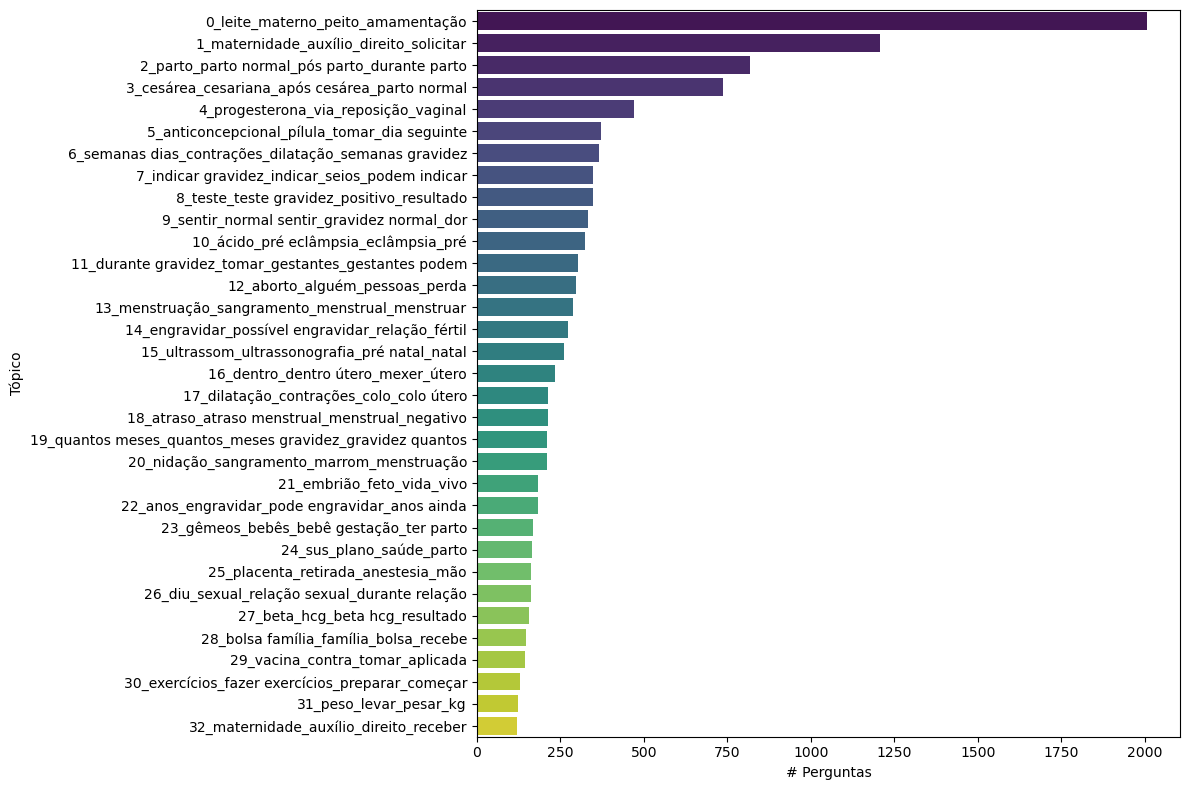

In [ ]:
plot_df = retained_final_df.copy()

plt.figure(figsize=(12, 8))
sns.countplot(y='Name', data=plot_df, order=plot_df['Name'].value_counts().index, palette='viridis')
plt.title('')
plt.xlabel('# Perguntas')
plt.ylabel('Tópico')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'topic_distribution.png'))
plt.show()
